# 03.3 — Feature Engineering (Comment ↔ Original Post Relation)

Continues from `03.2`: loads its checkpoint (`comments_df` with the section 6 per-comment features, plus the running `untrusted_features` list) and computes the same style of features for each comment's original post (OP), to see whether a relation between a comment's features and its OP's features helps predict persuasion.

> Loads `results/03_2_comments_df.csv` and `results/03_2_untrusted_features.json` (output of `03.2`).

In [8]:
import pandas as pd, json

comments_df = pd.read_csv('../results/03_2_comments_df.csv')
with open('../results/03_2_untrusted_features.json') as f:
    untrusted_features = json.load(f)

print(comments_df.shape)
print(untrusted_features)

(3971, 215)
['sentiment_vader', 'tone_label', 'style_label', 'ethos_score', 'pathos_score', 'logos_score']


## Setup

The helpers and Gemini setup below come from `common_functions.py` (shared with `03.1`), so nothing here is duplicated by hand. The two feature functions and the LLM prompts are still printed inline so the actual methodology stays visible without opening that file.

In [2]:
import re
import numpy as np
import common_functions

In [3]:
genai_client = common_functions.make_gemini_client()
GEMINI_MODEL = common_functions.DEFAULT_GEMINI_MODEL
from google.genai import errors as genai_errors

print(f"Using Gemini model: {GEMINI_MODEL}")

Using Gemini model: gemini-flash-latest


In [4]:
sentiment_llm_prompt_prefix = common_functions.SENTIMENT_LLM_PROMPT_PREFIX
user_prompt_prefix = common_functions.TONE_LLM_PROMPT_PREFIX
rhetorical_llm_prompt_prefix = common_functions.RHETORICAL_LLM_PROMPT_PREFIX
style_llm_prompt_prefix = common_functions.STYLE_LLM_PROMPT_PREFIX

print("sentiment_llm_prompt_prefix:")
print("----------------------------")
print(sentiment_llm_prompt_prefix)
print()

print("user_prompt_prefix:")
print("-------------------")
print(user_prompt_prefix)
print()

print("rhetorical_llm_prompt_prefix:")
print("-----------------------------")
print(rhetorical_llm_prompt_prefix)
print()

print("style_llm_prompt_prefix:")
print("------------------------")
print(style_llm_prompt_prefix)
print()

sentiment_llm_prompt_prefix:
----------------------------
Rate the sentiment of each of the following numbered texts on a scale from -1 (very negative) to 1 (very positive).

Base your score only on the tone and attitude of the person writing (e.g. hostile, dismissive, or rude vs. friendly, respectful, or warm) - NOT on how negative or positive the topic being discussed is. A calm, respectful discussion of a dark or violent topic should score close to neutral, not negative.

Reply with exactly one line per text, in the format "N: score" (matching the numbers below), and nothing else.

Texts:


user_prompt_prefix:
-------------------
Analyze the tone of each of the following numbered texts and classify it as one of the following: Logical, Passionate, Humorous, Sarcastic, Neutral, or Other.

Reply with exactly one line per text, in the format "N: label" (matching the numbers below), and nothing else.

Texts:


rhetorical_llm_prompt_prefix:
-----------------------------
Rate each of the f

In [5]:
do_calc_feature_op = common_functions.do_calc_feature_op

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

In [6]:
import inspect
print(inspect.getsource(common_functions.get_adjective_adverb_ratio))

get_adjective_adverb_ratio = common_functions.get_adjective_adverb_ratio

def get_adjective_adverb_ratio(text):
    doc = _get_nlp()(text)
    adjectives = [token.text for token in doc if token.pos_ == 'ADJ']
    adverbs = [token.text for token in doc if token.pos_ == 'ADV']
    return len(adjectives) / len(adverbs) if len(adverbs) > 0 else np.inf



In [7]:
print("EVIDENCE_STEMS:", common_functions.EVIDENCE_STEMS)
print("EVIDENCE_URL_EXTENSIONS:", common_functions.EVIDENCE_URL_EXTENSIONS)
print()
print(inspect.getsource(common_functions.get_evidence_count))

get_evidence_count = common_functions.get_evidence_count

EVIDENCE_STEMS: ['data', 'stat', 'statist', 'figur', '%', 'percent', 'averag', 'number', 'amount', 'thousand', 'million', 'billion', '$', '€', '¥', '£', 'dollar', 'evid', 'info', 'testimoni', 'conclus', 'document', 'experi', 'experi', 'measur', 'measur', 'report', 'result', 'census', 'figur', 'plot', 'graph', 'sum', 'total', 'decim', 'digit', 'fraction', 'numer', 'half', 'share', 'proport', 'capit', 'cash', 'properti', 'salari', 'wage', 'wealth', 'financ', 'resourc', 'roll', 'treasuri', 'bank', 'deposit', 'exchang', 'safe', 'estim', 'price', 'price', 'merchandis', 'retail', 'sale', 'cartel', 'invest', 'market', 'deposit', 'document', 'indic', 'wit', 'affirm', 'corrobor', 'declar', 'good', 'ground', 'token', 'signific', 'probabl', 'p valu', '<', '=', 'greater', 'equal', 'less', 'rang', 'devi', 'sd', 'mode', 'median']
EVIDENCE_URL_EXTENSIONS: ['http://', 'https://', '.com', '.org', '.gov', 'pdf', '.net', 'www.']

def get_evidence_count(text):
    evidence_count = 0
    comment_stemmed = 

# ７. The relation between comments and Original Post

We think that it is possible that a correlation between the comments style, tone etc. and the same features for the original post (OP) may be an indicator for the persuasion of a comment.

Therefore, we will create all the features also for the OP, and include them too as input for the model.

Since many of our commnets share the same original post, we will temporarily create a dataframe with the unique OPs. We will calculate the features for these unique values, and then we will copy these values into the original dataframe.

In [9]:
op_df = comments_df['original_post'].drop_duplicates()
op_df.reset_index(drop=True, inplace=True)
op_df = pd.DataFrame(op_df)
op_df

,original_post
0,CMV: Mike Bloomberg's campaign is proof that t...
1,CMV: Kanye West is a shill for president Trump...
2,CMV: Most Americans who oppose a national heal...
3,CMV: Donald Trump has not made a single lastin...
4,CMV: being a conservative is the least Christ-...
...,...
396,CMV: People that want to become elected offici...
397,CMV: You shouldn't be able to see how many upv...
398,CMV: White people can wear cornrows\nWhen my s...
399,CMV: Drugs shouldn't be criminalized unless yo...


## 7.1 Sentiment Analysis

VADER conflated topic with tone for comments (see 6.1), and the OP text covers the same kind of charged subject matter - so we skip VADER here and go straight to the LLM-based approach that worked there.

In [10]:
op_df['sentiment_llm_op'] = None

In [11]:
def get_sentiment_llm_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = sentiment_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  scores = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)', line)
    if match:
      i, score = int(match.group(1)), float(match.group(2))
      if 0 <= i < len(scores):
        scores[i] = score
  return scores

In [ ]:
BATCH_SIZE = 20

pending_index = op_df[op_df['sentiment_llm_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_sentiment_llm_op_batch([op_df.loc[i] for i in batch_index])
    for i, score in zip(batch_index, scores):
      op_df.at[i, 'sentiment_llm_op'] = score
    op_df.to_csv('../results/op_df_sentiment_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")

In [9]:
none_count = op_df['sentiment_llm_op'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(op_df)}")

All entries were classified!


In [36]:
op_df['sentiment_llm_op'] = pd.to_numeric(op_df['sentiment_llm_op'], errors='coerce')
op_df['sentiment_llm_op'].describe()

count    401.000000
mean       0.100998
std        0.321246
min       -0.800000
25%       -0.100000
50%        0.100000
75%        0.300000
max        0.800000
Name: sentiment_llm_op, dtype: float64

In [9]:
# sentiment_llm_op is constant across all of an OP's comments, so checking it against
# comment-level rows would over-weight OPs with many replies. Aggregate to one row per
# OP instead, so each OP counts equally regardless of how many comments it received.
comments_df['sentiment_llm_op'] = comments_df['original_post'].map(
    op_df.set_index('original_post')['sentiment_llm_op']
)
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

op_outcomes = comments_df.groupby('original_post').agg(
    convincing_rate=('is_convincing', 'mean'),
    n_convinced=('is_convincing', 'sum'),
    n_comments=('is_convincing', 'count'),
).reset_index()
op_outcomes = op_outcomes.merge(op_df[['original_post', 'sentiment_llm_op', 'tone_google_op']], on='original_post', how='left')

print(f"Mean of per-OP convincing rate: {op_outcomes['convincing_rate'].mean():.1%}  (n={len(op_outcomes)} OPs)")
print(f"Correlation between thread size (n_comments) and per-OP convincing rate: {op_outcomes['n_comments'].corr(op_outcomes['convincing_rate']):.2f}")

Mean of per-OP convincing rate: 42.8%  (n=401 OPs)
Correlation between thread size (n_comments) and per-OP convincing rate: -0.67


/var/folders/_0/fw_khfx97rs1j2m2d2xx1x400000gp/T/ipykernel_26264/3524642511.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  comments_df['sentiment_llm_op'] = comments_df['original_post'].map(


Aggregating to one row per OP - so each OP counts once regardless of comment count - gives a mean per-OP convincing rate of 42.8%, well above the ~16.1% comment-row baseline reported in 6.1. We won't break this down further by OP sentiment, though: thread size is itself strongly correlated with per-OP convincing rate (r=-0.67, printed above), because of how `02_data_annotation.ipynb` builds this dataset - positive rows come from delta comments (roughly constant per thread) while negative rows come only from leaf comments, which scale with thread size (see the note there). Any split by an OP-level feature risks just re-detecting thread size rather than anything about persuasion, so we won't lean on this univariate view. We'll keep `sentiment_llm_op` as a feature regardless, since a weak or confounded relationship might still combine usefully with other features - the match-based check below is a cleaner test.

In [14]:
# A different question: does the comment's own sentiment align with the OP's, rather
# than the OP's sentiment alone? Sentiment is continuous, so "match" means falling in
# the same positive/negative/neutral bucket, not exact equality.
def sentiment_bucket(x):
    return 'positive' if x > 0 else ('negative' if x < 0 else 'neutral')

comments_df['sentiment_match'] = (
    comments_df['sentiment_llm'].apply(sentiment_bucket)
    == comments_df['sentiment_llm_op'].apply(sentiment_bucket)
)
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

rate_table = comments_df.groupby('sentiment_match')['is_convincing'].agg(['mean', 'count'])
rate_table['mean'] = (rate_table['mean'] * 100).round(1)
rate_table.columns = ['convincing_rate_%', 'n']
rate_table

Baseline convincing rate: 16.1%



,convincing_rate_%,n
sentiment_match,,
False,14.3,2221
True,18.5,1750


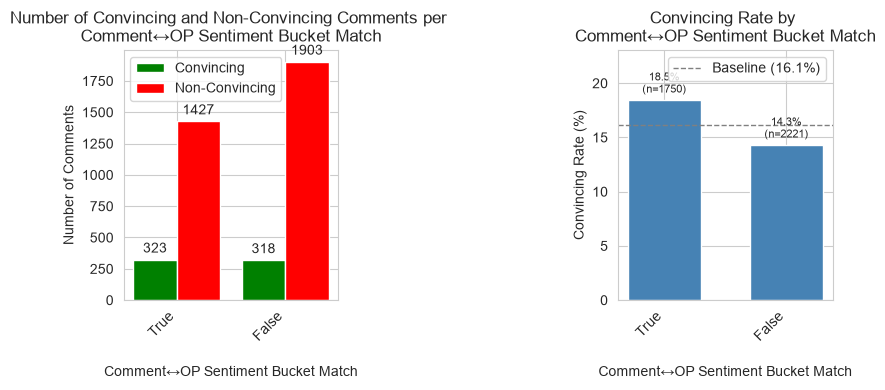

In [21]:
common_functions.plot_category_histogram(comments_df, 'sentiment_match', '\nComment↔OP Sentiment Bucket Match',
                                         show_counts=True, figsize=(4, 4), panel_gap=1.3)

Matching sentiment buckets shows a real, if modest, gap: 18.5% convincing (n=1,750) when the comment's sentiment bucket matches the OP's, vs. 14.3% (n=2,221) when it doesn't, against the ~16.1% baseline. That's the same direction as the OP-alone view above, but as a direct two-group comparison rather than a binned trend. We'll keep `sentiment_match` as a feature.

Since `sentiment_llm_op` and `sentiment_llm` are both already features in their own right, it's worth asking whether `sentiment_match` adds anything a model couldn't infer on its own from those two. That depends on the model: we plan to compare logistic regression and SVM alongside tree-based models (random forest, XGBoost), and the linear/margin-based ones only combine inputs additively - they have no built-in way to express "same sign as," so without this column that interaction would be invisible to them no matter how much data they see. Tree-based models can approximate it by splitting on both columns, but need more depth and data to reconstruct what the explicit boolean already states directly. Keeping `sentiment_match` as its own feature makes the interaction available to every model in the comparison, not just the tree-based ones.

In [11]:
# Does the size and direction of the gap between comment and OP sentiment matter, not just
# whether they land in the same bucket? A signed diff avoids the arbitrary bucket boundary
# that sentiment_match relies on (a comment at 0.01 and an OP at -0.01 count as a full
# mismatch there, despite being nearly identical).
comments_df['sentiment_diff'] = comments_df['sentiment_llm'] - comments_df['sentiment_llm_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

print(f"Correlation with is_convincing: {comments_df['sentiment_diff'].corr(comments_df['is_convincing']):.3f}")
comments_df['sentiment_diff'].describe()

Correlation with is_convincing: -0.000


/var/folders/_0/fw_khfx97rs1j2m2d2xx1x400000gp/T/ipykernel_62346/1640553099.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  comments_df['sentiment_diff'] = comments_df['sentiment_llm'] - comments_df['sentiment_llm_op']


count    3971.000000
mean       -0.026391
std         0.442410
min        -1.600000
25%        -0.300000
50%         0.000000
75%         0.200000
max         1.700000
Name: sentiment_diff, dtype: float64

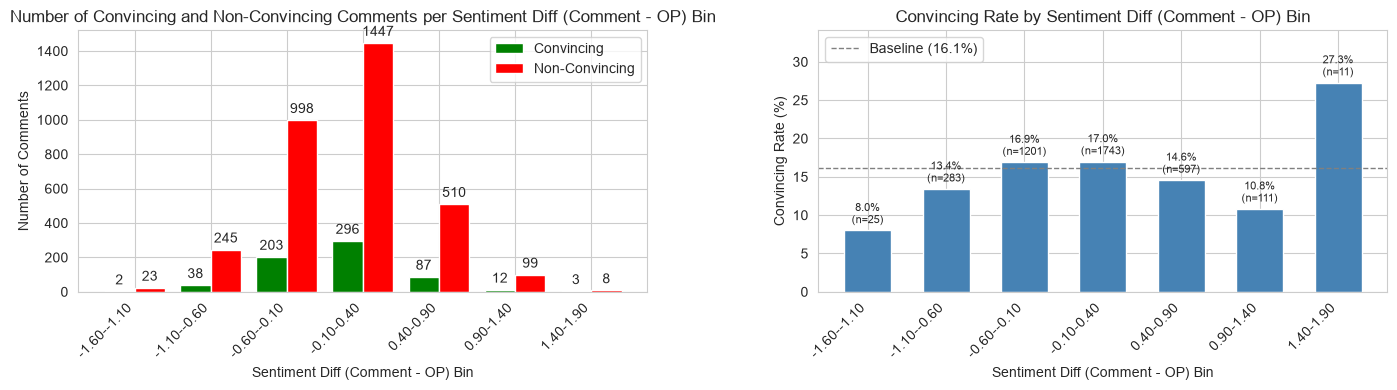

In [11]:
common_functions.plot_feature(comments_df, 'sentiment_diff', 'Sentiment Diff (Comment - OP)', 0.5, show_counts=True)

`sentiment_diff` doesn't show a real relationship: the correlation with `is_convincing` is essentially zero (-0.000, printed above), and the binned chart doesn't show a clean trend either - rates hover close to the ~16.1% baseline through most of the range (13.4%-17.0%), dip to 10.8% in the 0.9-1.4 bin (n=111), and the apparent jump to 27.3% in the top bin is only n=11, too small to trust. That's consistent with `sentiment_match` above: whatever signal exists in comment-OP sentiment alignment lives in the same-side-of-zero distinction that bucketing already captures, not in the diff's magnitude. We'll keep `sentiment_diff` as a feature for now, but the case for it is weak, and we'll likely lean on `sentiment_match` over it once we compare feature importances during modeling.

## 7.2 Tone

In [ ]:
op_df['tone_google_op'] = None

import re

def get_tone_from_google_ai_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = user_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  if response.text is None:
    reason = response.candidates[0].finish_reason if response.candidates else response.prompt_feedback
    raise common_functions.BlockedResponseError(f"empty response, likely safety-blocked (reason: {reason})")

  classifications = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(\w+)', line)
    if match:
      i, label = int(match.group(1)), match.group(2)
      if 0 <= i < len(classifications):
        classifications[i] = label
  return classifications


In [ ]:
BATCH_SIZE = 20

def classify_tone_batch_op(batch_index):
  try:
    classifications = get_tone_from_google_ai_op_batch([op_df.loc[i] for i in batch_index])
    for i, classification in zip(batch_index, classifications):
      op_df.at[i, 'tone_google_op'] = classification
  except common_functions.BlockedResponseError as e:
    if len(batch_index) == 1:
      print(f"row {batch_index[0]} has no usable response: {e} - marking as 'BLOCKED'")
      op_df.at[batch_index[0], 'tone_google_op'] = 'BLOCKED'
    else:
      mid = len(batch_index) // 2
      classify_tone_batch_op(batch_index[:mid])
      classify_tone_batch_op(batch_index[mid:])

pending_index = op_df[op_df['tone_google_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a label
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    classify_tone_batch_op(batch_index)
    op_df.to_csv('../results/op_df_tone_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [12]:
none_count = op_df['tone_google_op'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(op_df)}")

All entries were classified!


In [40]:
op_df.to_csv('../results/op_df_tone_checkpoint.csv', index=False)
comments_df.to_csv('../results/comments_df_op_tone_checkpoint.csv', index=False)

Same reasoning as 7.1: aggregating to one row per OP gives the same 42.8% mean per-OP convincing rate (computed above), and the same thread-size confound applies to any breakdown by OP tone category here. We'll keep `tone_google_op` as a feature, but rely on the match-based check below rather than this univariate view.

In [22]:
# Does the comment's own tone match the OP's tone label exactly?
comments_df['tone_google_op'] = comments_df['original_post'].map(
    op_df.set_index('original_post')['tone_google_op']
)
comments_df['tone_match'] = comments_df['tone_google'] == comments_df['tone_google_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

rate_table = comments_df.groupby('tone_match')['is_convincing'].agg(['mean', 'count'])
rate_table['mean'] = (rate_table['mean'] * 100).round(1)
rate_table.columns = ['convincing_rate_%', 'n']
rate_table

Baseline convincing rate: 16.1%



,convincing_rate_%,n
tone_match,,
False,12.3,2505
True,22.6,1466


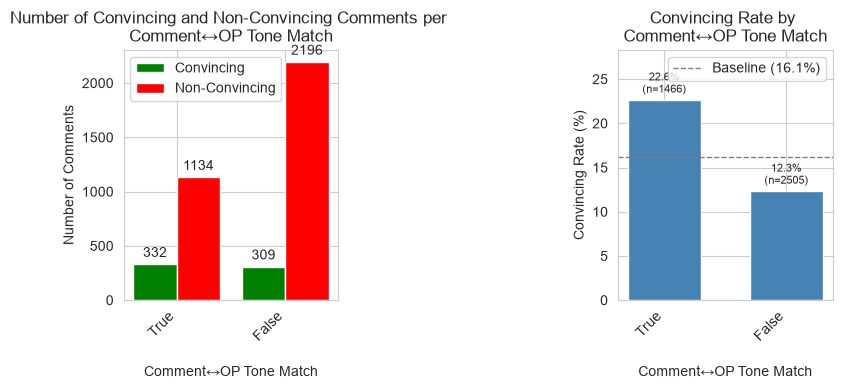

In [23]:
common_functions.plot_category_histogram(comments_df, 'tone_match', '\nComment↔OP Tone Match', show_counts=True, figsize=(4, 4), panel_gap=1.3)

This is the clearest relationship in this notebook so far: comments whose tone matches the OP's tone label convince at 22.6% (n=1,466), vs. 12.3% (n=2,505) when it doesn't, against a ~16.1% baseline. That's a bigger gap than anything in the OP-alone views above, and it fits a mirroring/rapport account of persuasion: meeting the OP's tone (logical-to-logical, passionate-to-passionate, etc.) seems to matter more than the OP's tone by itself. We'll keep `tone_match` as a feature.

## 7.3 Style

Same reasoning as 7.1: BART-large-MNLI's zero-shot labels already proved unreliable for comments (see 6.3) - `style_label` was marked untrusted there. We skip it here and go straight to the Gemini-based `style_google` approach.

In [47]:
op_df['style_google_op'] = None

import re

def get_style_from_google_ai_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = style_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  if response.text is None:
    reason = response.candidates[0].finish_reason if response.candidates else response.prompt_feedback
    raise common_functions.BlockedResponseError(f"empty response, likely safety-blocked (reason: {reason})")

  labels = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(\w+)', line)
    if match:
      i, label = int(match.group(1)), match.group(2)
      if 0 <= i < len(labels):
        labels[i] = label
  return labels

In [58]:
BATCH_SIZE = 20

def classify_style_batch_op(batch_index):
  try:
    labels = get_style_from_google_ai_op_batch([op_df.loc[i] for i in batch_index])
    for i, label in zip(batch_index, labels):
      op_df.at[i, 'style_google_op'] = label
  except common_functions.BlockedResponseError as e:
    if len(batch_index) == 1:
      print(f"row {batch_index[0]} has no usable response: {e} - marking as 'BLOCKED'")
      op_df.at[batch_index[0], 'style_google_op'] = 'BLOCKED'
    else:
      mid = len(batch_index) // 2
      classify_style_batch_op(batch_index[:mid])
      classify_style_batch_op(batch_index[mid:])

pending_index = op_df[op_df['style_google_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a label
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    classify_style_batch_op(batch_index)
    op_df.to_csv('../results/op_df_style_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")

classified rows 200-219


In [59]:
none_count = op_df['style_google_op'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(op_df)}")

All entries were classified!


In [60]:
op_df.to_csv('../results/op_df_style_checkpoint.csv', index=False)

Same reasoning as 7.1 and 7.2: aggregating to one row per OP gives the same 42.8% mean per-OP convincing rate (computed in 7.1), and the same thread-size confound applies to any breakdown by OP style category here. We'll keep `style_google_op` as a feature, but rely on the match-based check below rather than this univariate view.

In [24]:
# Does the comment's own style match the OP's style label exactly?
comments_df['style_google_op'] = comments_df['original_post'].map(
    op_df.set_index('original_post')['style_google_op']
)
comments_df['style_match'] = comments_df['style_google'] == comments_df['style_google_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

rate_table = comments_df.groupby('style_match')['is_convincing'].agg(['mean', 'count'])
rate_table['mean'] = (rate_table['mean'] * 100).round(1)
rate_table.columns = ['convincing_rate_%', 'n']
rate_table

Baseline convincing rate: 16.1%



,convincing_rate_%,n
style_match,,
False,18.9,518
True,15.7,3453


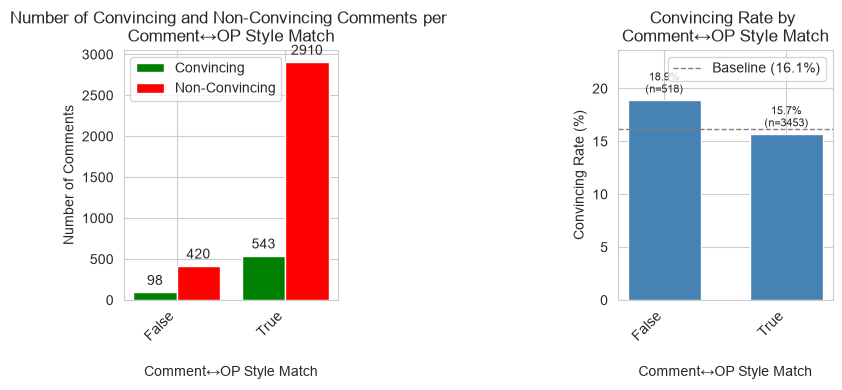

In [26]:
common_functions.plot_category_histogram(comments_df, 'style_match', '\nComment↔OP Style Match',
                                         show_counts=True, figsize=(4, 4), panel_gap=1.3)

Unlike `tone_match` and `sentiment_match` above, style matching shows essentially no signal, and if anything points the wrong way: comments whose style matches the OP's convince at 15.7% (n=3,453), while mismatches convince at 18.9% (n=518), against a ~16.1% baseline. That's likely just noise from a heavily skewed style distribution - both comments (94.4% `Informal`) and OPs (92.0% `Informal`, 369/401) are overwhelmingly informal, so the match group is dominated by informal-informal pairs sitting near baseline, while the much smaller mismatch group mixes two rarer sub-populations (formal comment/informal OP and vice versa). We'll keep `style_match` as a feature for consistency with `tone_match`/`sentiment_match`, but this one doesn't show the mirroring effect the other two did.

In [27]:
comments_df.to_csv('../results/comments_df_op_style_checkpoint.csv', index=False)

## 7.4 Rhetorical means

Same reasoning as 7.1: Empath's word-list approach already proved unreliable for comments (see 6.4), conflating topic with rhetorical strategy. We skip it here and go straight to the Gemini-based approach.

In [29]:
op_df['ethos_llm_op'] = None
op_df['pathos_llm_op'] = None
op_df['logos_llm_op'] = None

In [30]:
def get_rhetorical_llm_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = rhetorical_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  scores = [(None, None, None)] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)', line)
    if match:
      i = int(match.group(1))
      if 0 <= i < len(scores):
        scores[i] = (float(match.group(2)), float(match.group(3)), float(match.group(4)))
  return scores

In [ ]:
BATCH_SIZE = 20

pending_index = op_df[op_df['ethos_llm_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_rhetorical_llm_op_batch([op_df.loc[i] for i in batch_index])
    for i, (ethos, pathos, logos) in zip(batch_index, scores):
      op_df.at[i, 'ethos_llm_op'] = ethos
      op_df.at[i, 'pathos_llm_op'] = pathos
      op_df.at[i, 'logos_llm_op'] = logos
    op_df.to_csv('../results/op_df_rhetorical_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")

In [17]:
for feature in ['ethos_llm_op', 'pathos_llm_op', 'logos_llm_op']:
  none_count = op_df[feature].isna().sum()
  if none_count == 0:
    print(f"{feature}: all entries were classified!")
  else:
    print(f"{feature}: {none_count} entries still need to be classified out of {len(op_df)}")

ethos_llm_op: all entries were classified!
pathos_llm_op: all entries were classified!
logos_llm_op: all entries were classified!


In [ ]:
op_df.to_csv('../results/op_df_rhetorical_checkpoint.csv', index=False)

In [20]:
for feature in ['ethos_llm_op', 'pathos_llm_op', 'logos_llm_op']:
  op_df[feature] = pd.to_numeric(op_df[feature], errors='coerce')

op_df[['ethos_llm_op', 'pathos_llm_op', 'logos_llm_op']].describe()

,ethos_llm_op,pathos_llm_op,logos_llm_op
count,401.000000,401.000000,401.000000
mean,0.378055,0.483292,0.714464
std,0.167682,0.184513,0.123249
min,0.100000,0.000000,0.200000
25%,0.300000,0.300000,0.600000
50%,0.400000,0.500000,0.700000
75%,0.500000,0.600000,0.800000
max,0.900000,0.900000,0.900000


Same reasoning as 7.1-7.3: aggregating to one row per OP gives the same 42.8% mean per-OP convincing rate (computed in 7.1), and the same thread-size confound applies to any breakdown by OP-level ethos/pathos/logos here. We'll keep `ethos_llm_op`, `pathos_llm_op`, and `logos_llm_op` as features, but rely on the match-based check below rather than this univariate view.

In [21]:
# Ethos/pathos/logos are continuous 0-1 scores rather than a single signed value or a
# category label, so "match" follows the same high/low split used for these scores in
# 6.4 (>= 0.5 vs below): does the comment's bucket match the OP's bucket, for each of
# the three appeals independently?
def rhetorical_bucket(x):
  return 'high' if x >= 0.5 else 'low'

for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  op_feature = f'{feature}_op'
  match_col = feature.replace('_llm', '_match')
  comments_df[op_feature] = comments_df['original_post'].map(op_df.set_index('original_post')[op_feature])
  comments_df[match_col] = (
      comments_df[feature].apply(rhetorical_bucket) == comments_df[op_feature].apply(rhetorical_bucket)
  )
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  match_col = feature.replace('_llm', '_match')
  rate_table = comments_df.groupby(match_col)['is_convincing'].agg(['mean', 'count'])
  rate_table['mean'] = (rate_table['mean'] * 100).round(1)
  rate_table.columns = ['convincing_rate_%', 'n']
  print(f"--- {match_col} ---")
  print(rate_table)
  print()

Baseline convincing rate: 16.1%

--- ethos_match ---
             convincing_rate_%     n
ethos_match                         
False                     18.9  1519
True                      14.4  2452

--- pathos_match ---
              convincing_rate_%     n
pathos_match                         
False                      16.2  1915
True                       16.1  2056

--- logos_match ---
             convincing_rate_%     n
logos_match                         
False                      4.5   946
True                      19.8  3025



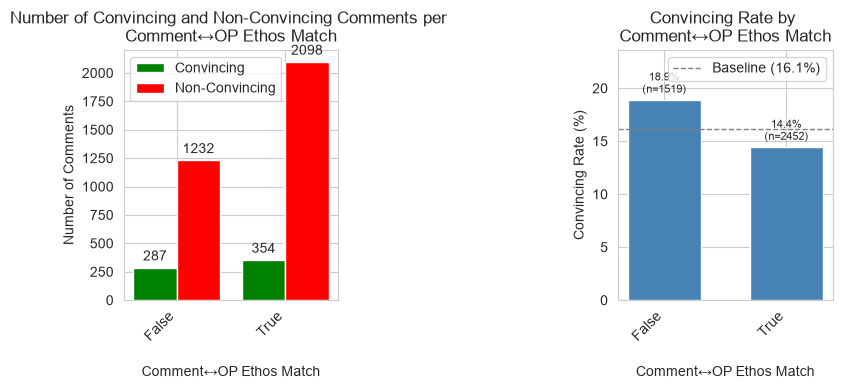

In [15]:
common_functions.plot_category_histogram(comments_df, 'ethos_match', '\nComment↔OP Ethos Match', show_counts=True, figsize=(4, 4), panel_gap=1.3)

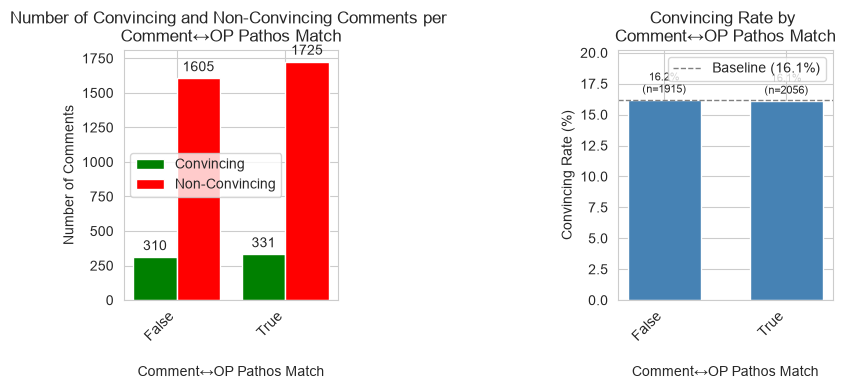

In [16]:
common_functions.plot_category_histogram(comments_df, 'pathos_match', '\nComment↔OP Pathos Match', show_counts=True, figsize=(4, 4), panel_gap=1.3)

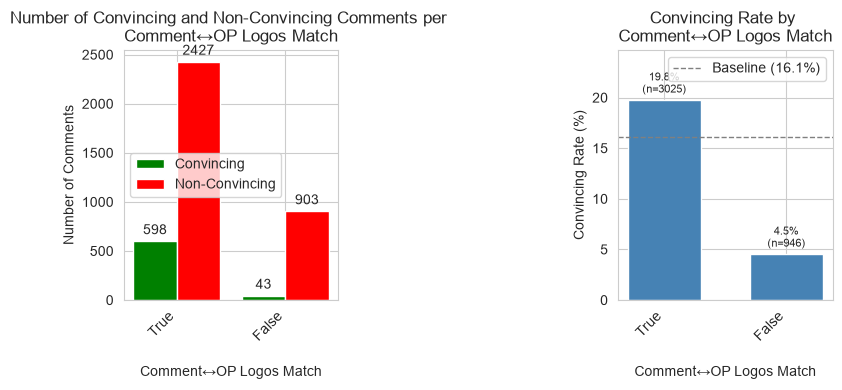

In [17]:
common_functions.plot_category_histogram(comments_df, 'logos_match', '\nComment↔OP Logos Match', show_counts=True, figsize=(4, 4), panel_gap=1.3)

In [22]:
# A "match" rate can just be re-detecting a comment's own high/low score, rather than
# actual OP mirroring, if one bucket dominates the OP side (little to mirror against)
# or if the "match" group itself pools together very different sub-populations. Check both.
for feature in ['ethos_llm_op', 'pathos_llm_op', 'logos_llm_op']:
  high_share = (op_df[feature] >= 0.5).mean()
  print(f"{feature}: {high_share:.1%} of OPs bucket 'high'")
print()

ethos_breakdown = comments_df.groupby(
    [comments_df['ethos_llm'].apply(rhetorical_bucket), comments_df['ethos_llm_op'].apply(rhetorical_bucket)]
)['is_convincing'].agg(['mean', 'count'])
ethos_breakdown.index.names = ['comment_bucket', 'op_bucket']
ethos_breakdown['mean'] = (ethos_breakdown['mean'] * 100).round(1)
ethos_breakdown.columns = ['convincing_rate_%', 'n']
ethos_breakdown

ethos_llm_op: 32.2% of OPs bucket 'high'
pathos_llm_op: 60.1% of OPs bucket 'high'
logos_llm_op: 97.0% of OPs bucket 'high'



convincing_rate_%     n
comment_bucket op_bucket                         
high           high                    22.6   381
               low                     22.3   745
low            high                    15.6   774
               low                     12.9  2071

All three rhetorical matches land differently, and none of them repeats the tone_match/sentiment_match mirroring story cleanly:

`logos_match` shows the widest gap in this notebook - 19.8% convincing (n=3,025) when the comment's logos bucket matches the OP's, vs. 4.5% (n=946) when it doesn't, against the ~16.1% baseline. But the OP side is barely varying: 97.0% of OPs bucket 'high' on logos (printed above), so there's almost nothing to mirror against. `logos_match` is mostly just re-deriving the comment's own logos_llm bucket, which we already know is a strong predictor on its own (19.8% vs. 3.8% in 6.4) - not evidence of genuine OP-comment mirroring.

`pathos_match` is essentially flat - 16.2% (n=1,915) vs. 16.1% (n=2,056) - consistent with `pathos_llm` being flat on its own in 6.4.

`ethos_match` is the odd one out: matching actually convinces *worse* (14.4%, n=2,452) than mismatching (18.9%, n=1,519), the opposite direction from `tone_match`/`sentiment_match`. The breakdown above explains why: convincing rate tracks the comment's own ethos bucket almost regardless of the OP (22.6% comment-high/OP-high vs. 22.3% comment-high/OP-low), while low-ethos comments do worse whichever OP bucket they land in (15.6% vs. 12.9%). `ethos_match` pools the best group (high/high, n=381) together with the worst and largest group (low/low, n=2,071), so the "match" label mixes two very different populations instead of isolating a real mirroring effect.

We'll keep `ethos_match`, `pathos_match`, and `logos_match` as features regardless, in case a model finds a conditional signal the raw group averages don't show - but unlike `tone_match`, none of the three add a clean match-based signal beyond what the standalone comment-level scores already capture.

In [23]:
# Same idea as sentiment_diff in 7.1: does the signed gap between comment and OP score carry
# more signal than the high/low bucket match did, especially for ethos_match above, whose
# match/mismatch groups turned out to pool very different sub-populations together?
for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  diff_col = feature.replace('_llm', '_diff')
  comments_df[diff_col] = comments_df[feature] - comments_df[f'{feature}_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  diff_col = feature.replace('_llm', '_diff')
  corr = comments_df[diff_col].corr(comments_df['is_convincing'])
  print(f"{diff_col}: corr with is_convincing = {corr:.3f}")

ethos_diff: corr with is_convincing = 0.114
pathos_diff: corr with is_convincing = -0.025
logos_diff: corr with is_convincing = 0.219


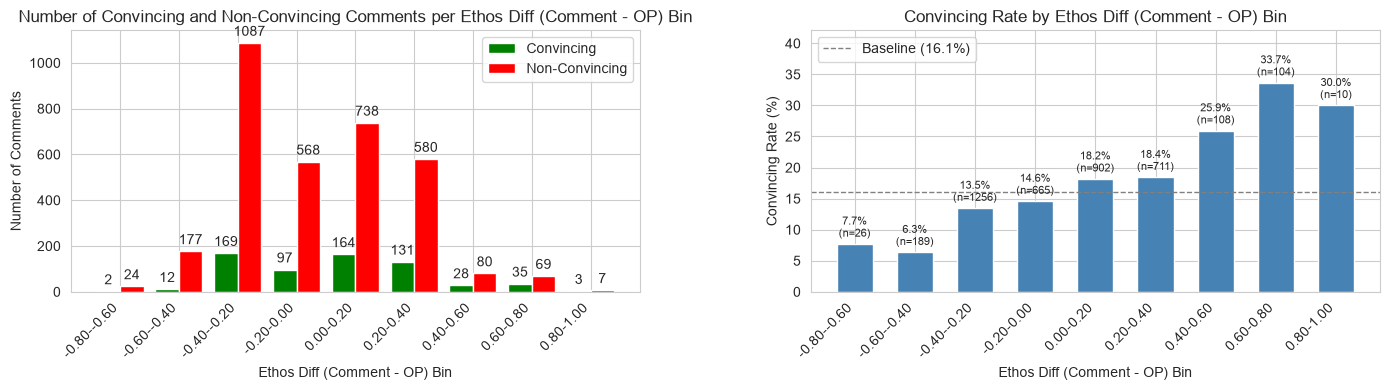

In [20]:
common_functions.plot_feature(comments_df, 'ethos_diff', 'Ethos Diff (Comment - OP)', 0.2, show_counts=True)

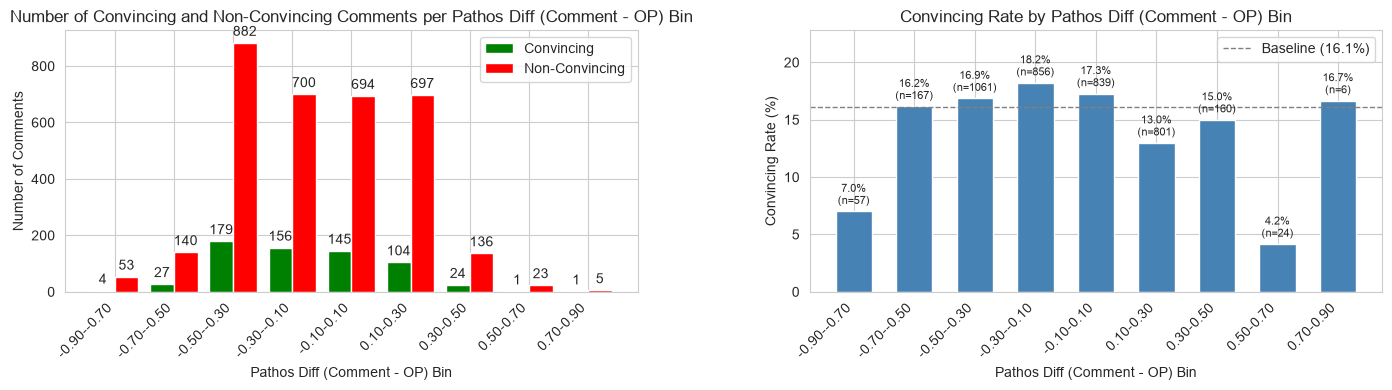

In [21]:
common_functions.plot_feature(comments_df, 'pathos_diff', 'Pathos Diff (Comment - OP)', 0.2, show_counts=True)

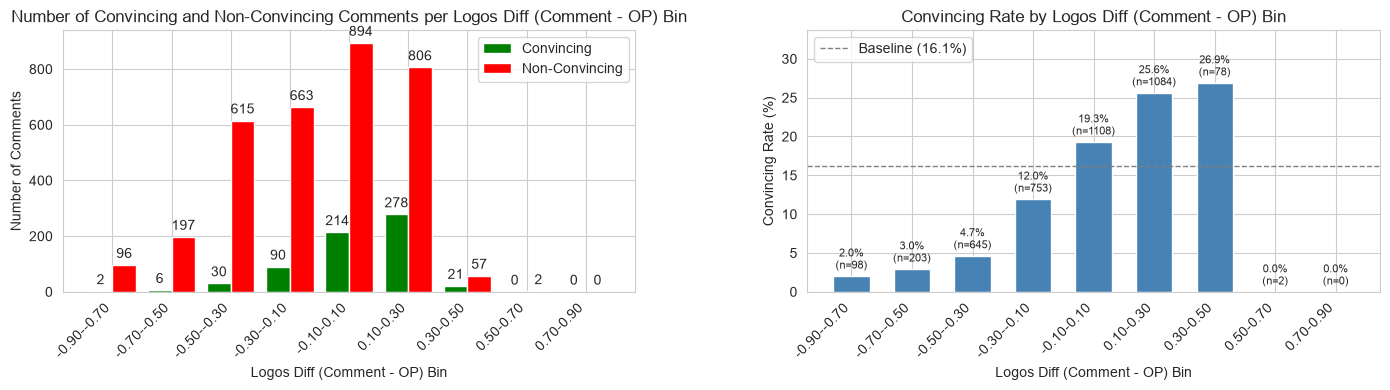

In [22]:
common_functions.plot_feature(comments_df, 'logos_diff', 'Logos Diff (Comment - OP)', 0.2, show_counts=True)

The diffs tell a cleaner story than the matches above, and in two cases a genuinely different one:

`logos_diff` has the strongest correlation with `is_convincing` of any continuous feature in this notebook (r=0.219, printed above), and the binned chart is close to monotonic: 2.0% convincing at the most negative bin (n=98) climbing fairly steadily to 25.6% (n=1,084) and 26.9% (n=78) at the positive end, crossing the ~16.1% baseline right around zero. This is a real improvement over `logos_match`: that boolean was mostly re-detecting the comment's own logos_llm bucket, because 97.0% of OPs bucket 'high' and there was almost no OP-side variation to match against. `logos_diff` doesn't have that problem - it's a continuous signed comparison, not a threshold - and it captures the same underlying relationship without the confound.

`ethos_diff` also shows a real, fairly monotonic relationship (r=0.114): 6.3%-7.7% convincing at the most negative bins climbing to 25.9%-33.7% at the most positive ones (though the top bins get thin, n=104 and n=108). This resolves the `ethos_match` paradox from above cleanly: `ethos_match` showed matching doing *worse* than mismatching, which only made sense once we saw it was pooling the best group (high/high) with the worst (low/low). `ethos_diff` doesn't pool anything - it says plainly that a comment scoring higher on ethos than its OP tends to convince more, which is the coherent version of the story the match boolean muddled.

`pathos_diff` stays flat (r=-0.025), consistent with `pathos_llm` and `pathos_match` both being uninformative in every form we've tried - no version of "pathos" we've measured relates to persuasion here.

`logos_diff` and `ethos_diff` look like real upgrades over their match counterparts - continuous, not confounded by OP-side skew or by pooling opposite subgroups. We'll keep the match booleans alongside the diffs for now rather than removing them outright, and decide based on feature importance once we compare models in `04_model_training.ipynb`.

In [25]:
op_df.to_csv('../results/comments_df_op_rhetorical_checkpoint.csv', index=False)

## 7.5 Adjective-Adverb Ratio

In [27]:
op_df['adj_adv_ratio_op'] = None

In [ ]:
do_calc_feature_op(op_df, "adj_adv_ratio_op", get_adjective_adverb_ratio)

In [29]:
op_df['adj_adv_ratio_op'].describe()

count     401.0
unique    252.0
top         1.0
freq       14.0
Name: adj_adv_ratio_op, dtype: float64

In [30]:
op_df['adj_adv_ratio_op'].replace(np.inf, 0).astype(float).describe()

count    401.000000
mean       1.625335
std        0.859342
min        0.000000
25%        1.125000
50%        1.444444
75%        1.888889
max        8.666667
Name: adj_adv_ratio_op, dtype: float64

Rows with zero adverbs get an infinite ratio, same as for comments in 6.5, and need the same kind of sentinel capping to stay plottable. But the sentinel isn't a real measurement - it's a stand-in for "undefined ratio" - so it should mean the same thing everywhere it's used. If we derived a separate sentinel from `op_df`'s own (smaller) finite max, a comment and its OP could both have an undefined ratio yet end up with different numbers, which would corrupt any future comparison between the two (e.g. `adj_adv_ratio_diff` below, following the same pattern as `sentiment_diff`/`ethos_diff` earlier). We reuse `comments_df`'s sentinel instead, with a sanity check that it's still larger than any genuine finite ratio on the OP side.

In [31]:
sentinel = comments_df['adj_adv_ratio'].max()  # already capped at its sentinel in 6.5

op_finite_max = op_df['adj_adv_ratio_op'].replace(np.inf, np.nan).max()
assert op_finite_max < sentinel, f"OP-level finite max ({op_finite_max}) exceeds comments_df's sentinel ({sentinel}) - reusing it would no longer rank infinite rows highest"

op_df['adj_adv_ratio_op'] = op_df['adj_adv_ratio_op'].replace(np.inf, sentinel).astype(float)

In [32]:
op_df['adj_adv_ratio_op'].describe()

count    401.000000
mean       1.667729
std        1.149354
min        0.363636
25%        1.125000
50%        1.444444
75%        1.888889
max       17.000000
Name: adj_adv_ratio_op, dtype: float64

In [33]:
op_df.to_csv('../results/op_df_adj_adv_ratio_checkpoint.csv', index=False)

Same reasoning as 7.1-7.4: an OP-level breakdown of `adj_adv_ratio_op` against per-OP convincing rate would hit the same thread-size confound, so we won't repeat that univariate view here. Instead we go straight to a diff comparison against the comment's own ratio, following the same pattern as `sentiment_diff`/`ethos_diff`/`pathos_diff`/`logos_diff` above - and since both columns share the same sentinel, that comparison is actually meaningful for every number, including the sentinel.

In [34]:
comments_df['adj_adv_ratio_op'] = comments_df['original_post'].map(op_df.set_index('original_post')['adj_adv_ratio_op'])
comments_df['adj_adv_ratio_diff'] = comments_df['adj_adv_ratio'] - comments_df['adj_adv_ratio_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

print(f"Correlation with is_convincing: {comments_df['adj_adv_ratio_diff'].corr(comments_df['is_convincing']):.3f}")
comments_df['adj_adv_ratio_diff'].describe()

Correlation with is_convincing: -0.080


count    3971.000000
mean        1.331947
std         4.764463
min       -17.000000
25%        -0.714866
50%        -0.113636
75%         0.701190
max        16.513514
Name: adj_adv_ratio_diff, dtype: float64

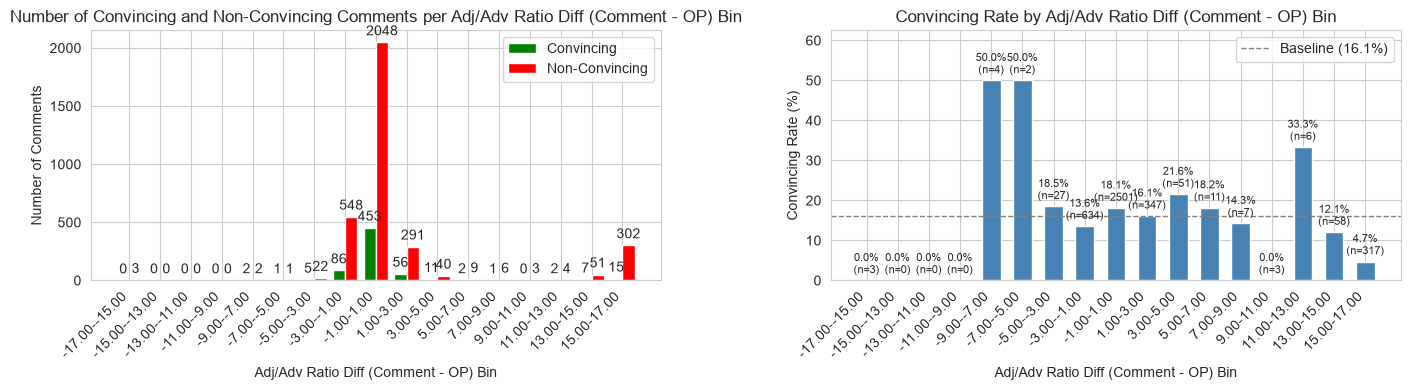

In [43]:
common_functions.plot_feature(comments_df, 'adj_adv_ratio_diff', 'Adj/Adv Ratio Diff (Comment - OP)', 2, show_counts=True)

In [44]:
# The sentinel cap is common on the comment side (short texts often have zero adverbs) but
# rare on the OP side (OPs are much longer). Check whether the diff's correlation is actually
# just this asymmetry showing up again, rather than a real comment-vs-OP effect.
sentinel_involved = (comments_df['adj_adv_ratio'] == sentinel) | (comments_df['adj_adv_ratio_op'] == sentinel)
print(f"Rows where either side is capped at the sentinel: {sentinel_involved.sum()} of {len(comments_df)}")
print(f"Convincing rate, sentinel-involved rows: {comments_df.loc[sentinel_involved, 'is_convincing'].mean():.1%}")
print(f"Convincing rate, remaining (clean) rows: {comments_df.loc[~sentinel_involved, 'is_convincing'].mean():.1%}")

clean = comments_df[~sentinel_involved]
print(f"Correlation with is_convincing, clean rows only: {clean['adj_adv_ratio_diff'].corr(clean['is_convincing']):.3f}")

Rows where either side is capped at the sentinel: 384 of 3971
Convincing rate, sentinel-involved rows: 6.0%
Convincing rate, remaining (clean) rows: 17.2%
Correlation with is_convincing, clean rows only: 0.018


In [39]:
comment_sentinel = comments_df['adj_adv_ratio'] == sentinel
op_sentinel = comments_df['adj_adv_ratio_op'] == sentinel

print(f"Comment-side sentinel only: {(comment_sentinel & ~op_sentinel).sum()}")
print(f"OP-side sentinel only: {(~comment_sentinel & op_sentinel).sum()}")
print(f"Both sides sentinel: {(comment_sentinel & op_sentinel).sum()}")
print(f"Neither (clean): {(~comment_sentinel & ~op_sentinel).sum()}")
print(f"Unique OPs with zero adverbs (OP-level sentinel): {(op_df['adj_adv_ratio_op'] == sentinel).sum()} of {len(op_df)}")

Comment-side sentinel only: 377
OP-side sentinel only: 3
Both sides sentinel: 4
Neither (clean): 3587
Unique OPs with zero adverbs (OP-level sentinel): 1 of 401


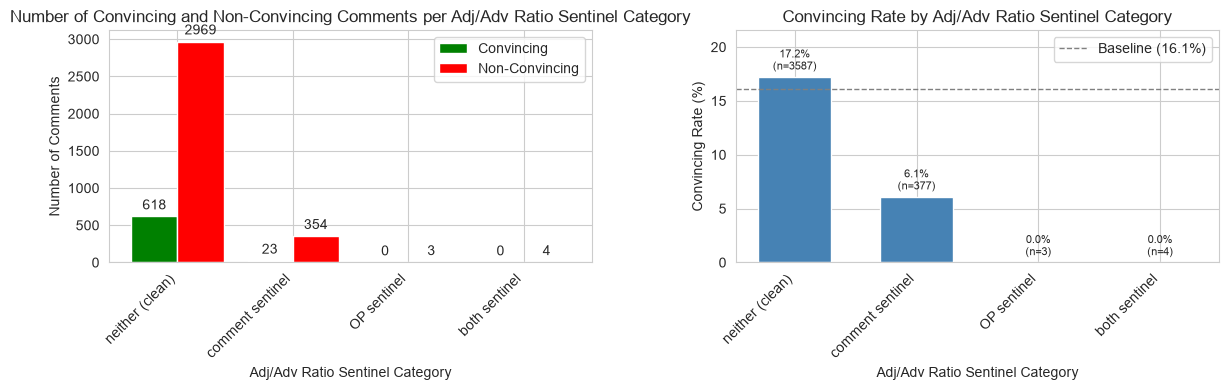

In [45]:
sentinel_category = np.select(
    [
        comment_sentinel & op_sentinel,
        comment_sentinel & ~op_sentinel,
        ~comment_sentinel & op_sentinel,
    ],
    ['both sentinel', 'comment sentinel', 'OP sentinel'],
    default='neither (clean)',
)
temp_df = comments_df.assign(adj_adv_ratio_sentinel_category=sentinel_category)
common_functions.plot_category_histogram(temp_df, 'adj_adv_ratio_sentinel_category', 'Adj/Adv Ratio Sentinel Category', show_counts=True)

The category breakdown above (counts printed in the previous cell) confirms the asymmetry: 377 comments hit the sentinel on their own side with a normal OP, only 3 have the reverse, and 4 have both sides capped. At the OP level only 1 of the 401 OPs ever has zero adverbs - OPs are long enough that this is essentially a comment-side phenomenon, so the "comment sentinel" bar above is doing almost all of the work in the sentinel-involved group's low convincing rate.

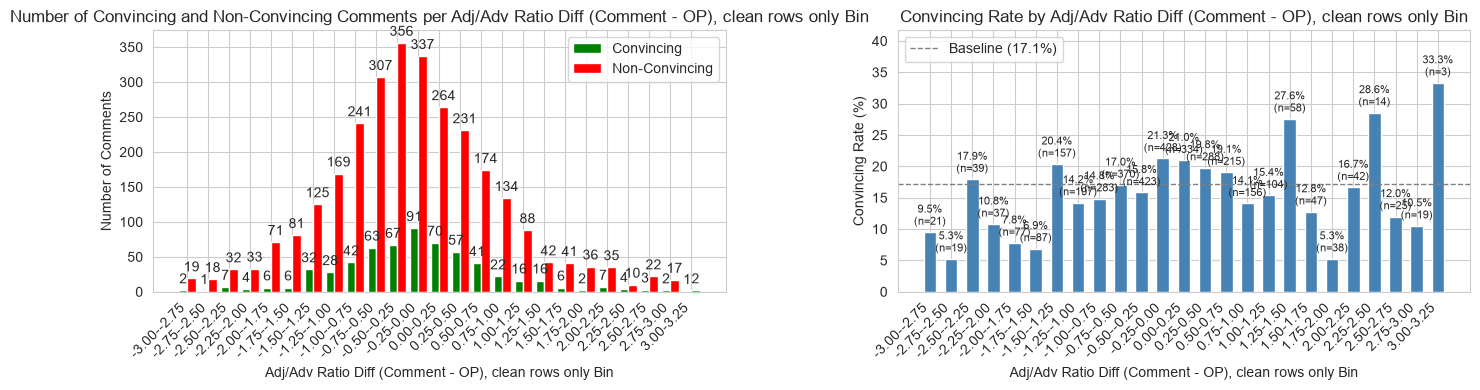

In [46]:
# 97% of clean rows fall within [-3, 3]; the rest are a long, sparse tail that would force
# coarse bins here too if included, so they're excluded to actually zoom in on the main range.
clean_main_range = clean[clean['adj_adv_ratio_diff'].between(-3, 3)]
common_functions.plot_feature(clean_main_range, 'adj_adv_ratio_diff', 'Adj/Adv Ratio Diff (Comment - OP), clean rows only', 0.25, show_counts=True)

Zooming into the main range after excluding the sentinel-involved rows shows what the clean correlation (r=0.018, printed above) already implied: the convincing rate is essentially flat across bins once the zero-adverb artifact is removed, with no visible trend from one side of the range to the other.

The raw `adj_adv_ratio_diff` correlation (r=-0.080, printed above) turns out to be almost entirely an artifact rather than a real comment-vs-OP effect. 384 of 3,971 rows (9.7%) have either the comment or the OP capped at the sentinel, and those rows convince at only 6.0% vs. 17.2% for the remaining "clean" rows (baseline `~16.1%`) - but that gap is just re-deriving 6.5's own finding that zero-adverb comments convince far less often than comments with a measurable ratio (~6% vs. ~17% there too), since 377 of these 384 rows are cases where the *comment* (not the OP) is the one hitting the sentinel. Only 1 of 401 OPs ever has zero adverbs - OPs are long enough that this is rare - so there's very little genuine OP-side variation for the diff to compare against, similar to the `logos_match` confound in 7.4. Once the sentinel-involved rows are excluded, the correlation drops to essentially zero (r=0.018), confirming there's no real relationship in the "clean" two-sided comparison.

We'll keep `adj_adv_ratio_diff` as a feature for consistency with the other diffs, but it's a weak addition: whatever signal it carries is already available from `adj_adv_ratio` alone (specifically, whether the comment itself hit the zero-adverb sentinel), not from anything about the OP.

In [37]:
comments_df.to_csv('../results/comments_df_op_adj_adv_ratio_checkpoint.csv', index=False)

## 7.6 Readability - Grade Level

In [ ]:
op_df['fk_grade_level_op'] = None

import textstat
do_calc_feature_op(op_df, "fk_grade_level_op", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

In [49]:
op_df['fk_grade_level_op'] = pd.to_numeric(op_df['fk_grade_level_op'], errors='coerce')

In [50]:
op_df['fk_grade_level_op'].describe()

count    401.000000
mean      10.955966
std        3.274184
min        4.252579
25%        9.032777
50%       10.824557
75%       12.349772
max       46.039101
Name: fk_grade_level_op, dtype: float64

The OP-level distribution (above) centers around an 11th-grade reading level (mean 10.96, std 3.27) and ranges from 4.25 up to a high outlier of 46.04. Flesch-Kincaid grade level has no upper cap, so a single long, run-on OP with unusually dense prose can push a score far above what "46th grade" would literally suggest - a property of the metric, not necessarily a data problem.

In [51]:
op_df.to_csv('../results/op_df_fk_grade_level_checkpoint.csv', index=False)

Same reasoning as 7.1-7.5: an OP-level breakdown of `fk_grade_level_op` against per-OP convincing rate would hit the same thread-size confound noted in 7.1, so we won't repeat that univariate view here. Instead we go straight to a diff comparison against the comment's own `fk_grade_level`, following the same pattern as `adj_adv_ratio_diff` above.

In [52]:
comments_df['fk_grade_level_op'] = comments_df['original_post'].map(op_df.set_index('original_post')['fk_grade_level_op'])
comments_df['fk_grade_level_diff'] = comments_df['fk_grade_level'] - comments_df['fk_grade_level_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

print(f"Correlation with is_convincing: {comments_df['fk_grade_level_diff'].corr(comments_df['is_convincing']):.3f}")
comments_df['fk_grade_level_diff'].describe()

Correlation with is_convincing: 0.090


count    3971.000000
mean       -1.807339
std         4.438123
min       -35.094511
25%        -4.341289
50%        -1.839119
75%         0.702520
max        38.658900
Name: fk_grade_level_diff, dtype: float64

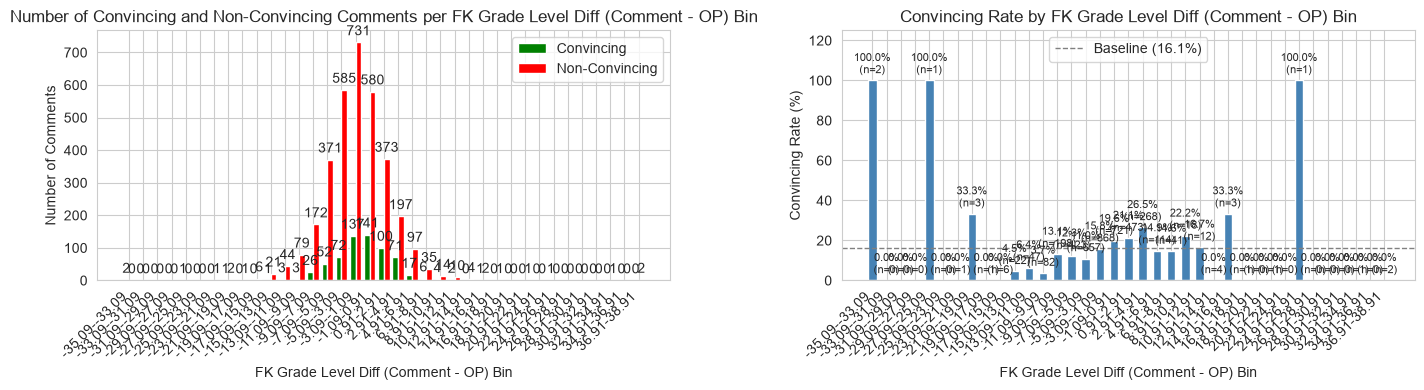

In [53]:
common_functions.plot_feature(comments_df, 'fk_grade_level_diff', 'FK Grade Level Diff (Comment - OP)', 2, show_counts=True)

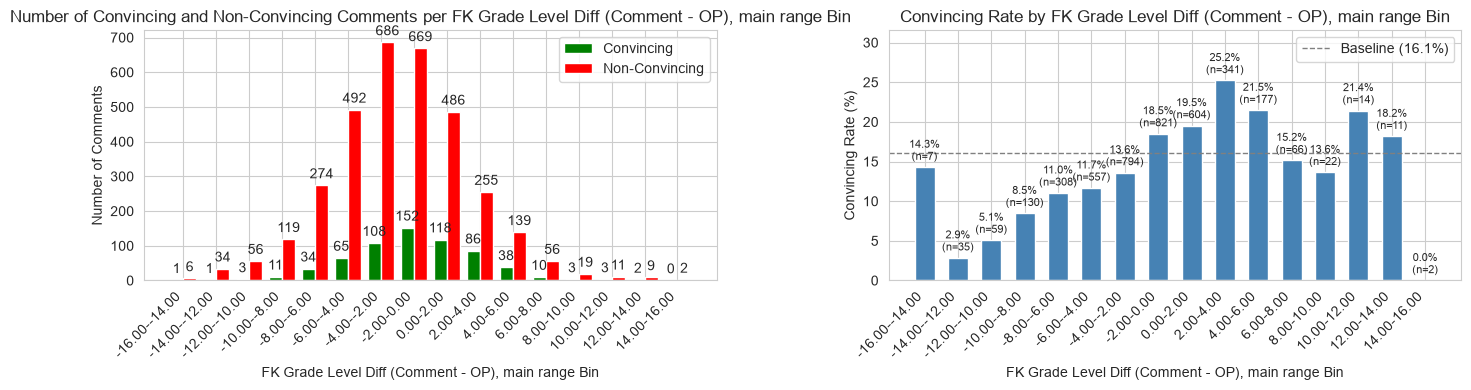

In [58]:
# 99.4% of rows fall within [-15, 15]; the remaining 23 stragglers sit in bins with
# single-digit counts that showed pure 0%/100% noise in the full chart above, not
# real signal. Zooming in here makes the actual trend visible. bin_anchor=0 keeps 0
# itself on a bin edge, so no bin mixes negative and positive diffs together.
main_range = comments_df[comments_df['fk_grade_level_diff'].between(-15, 15)]
common_functions.plot_feature(main_range, 'fk_grade_level_diff', 'FK Grade Level Diff (Comment - OP), main range', 2, show_counts=True, bin_anchor=0)

In [59]:
print(f"Correlation with is_convincing, main range only: {main_range['fk_grade_level_diff'].corr(main_range['is_convincing']):.3f}")

Correlation with is_convincing, main range only: 0.108


The full-range chart above is dominated by noise: with 37 bins spanning -35 to +38, most of the extreme ones hold only 1-3 comments, so a single case swings the bar to 0% or 100% - that's not signal, just what happens when you bin a handful of stragglers. The zoomed chart restricts to the 99.4% of rows within [-15, 15] (n=3,948) and anchors the bins at 0, so every bin sits cleanly on one side or the other - no bin blends a negative diff with a positive one.

With that, the trend the correlation implies actually becomes visible: setting aside the thinnest edge bins (n=7 and n=2), convincing rate climbs steadily through the negative range, from 2.9% (n=35) up to 18.5% (n=821) in the bin right before zero, continues to 19.5% (n=604) just after zero, and peaks at 25.2% (n=341) in the [2, 4) bin, where the comment reads 2-4 grade levels *above* its OP. The correlation on this main range alone (r=0.108, printed above) is actually a bit stronger than the r=0.090 over the full data, confirming the excluded stragglers were diluting the signal rather than carrying it. Past the peak the bins thin out fast (n<70) and the rate wobbles (15.2%, then 13.6%, 21.4%, 18.2%), so we still shouldn't over-read the far tail - but the moderate range now shows a real, legible relationship: comments written a bit more complex than their OP tend to convince somewhat more often.

In [54]:
comments_df.to_csv('../results/comments_df_op_fk_grade_level_checkpoint.csv', index=False)

## 7.7 Readability - Reading Ease

In [ ]:
op_df['fk_reading_ease_op'] = None

do_calc_feature_op(op_df, "fk_reading_ease_op", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

In [61]:
op_df['fk_reading_ease_op'] = pd.to_numeric(op_df['fk_reading_ease_op'], errors='coerce')

In [62]:
op_df['fk_reading_ease_op'].describe()

count    401.000000
mean      55.920963
std       11.551033
min      -35.234078
25%       48.975000
50%       55.954114
75%       63.352030
max       84.803921
Name: fk_reading_ease_op, dtype: float64

The OP-level distribution (above) centers in the middle of the reading-ease scale (mean 55.92, std 11.55) - roughly "fairly difficult" on the standard Flesch scale, consistent with the moderate grade level found in 7.6. As in 7.6, the metric has no natural floor: the lowest score here is -35.23, well below the scale's usual 0-100 range.

In [63]:
print(f"Correlation between fk_grade_level_op and fk_reading_ease_op: {op_df['fk_grade_level_op'].corr(op_df['fk_reading_ease_op']):.3f}")

Correlation between fk_grade_level_op and fk_reading_ease_op: -0.905


The strong negative correlation above (r=-0.905) confirms that reading ease is measuring essentially the same thing as `fk_grade_level_op` in 7.6, just inverted - the two features will likely tell the same story from opposite directions.

In [71]:
# Check whether fk_reading_ease is redundant with fk_grade_level at the comment level
# too, before deciding whether it's worth building out separate OP-relation features
# for it the way we did for fk_grade_level in 7.6.
comments_df['fk_reading_ease_op'] = comments_df['original_post'].map(op_df.set_index('original_post')['fk_reading_ease_op'])
comments_df['fk_reading_ease_diff'] = comments_df['fk_reading_ease'] - comments_df['fk_reading_ease_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

print(f"Comment-level correlation, fk_grade_level vs fk_reading_ease: {comments_df['fk_grade_level'].corr(comments_df['fk_reading_ease']):.3f}")
print(f"Diff-level correlation, fk_grade_level_diff vs fk_reading_ease_diff: {comments_df['fk_grade_level_diff'].corr(comments_df['fk_reading_ease_diff']):.3f}")
print()
print(f"Correlation with is_convincing - fk_grade_level: {comments_df['fk_grade_level'].corr(comments_df['is_convincing']):.3f}")
print(f"Correlation with is_convincing - fk_reading_ease: {comments_df['fk_reading_ease'].corr(comments_df['is_convincing']):.3f}")
print(f"Correlation with is_convincing - fk_grade_level_diff: {comments_df['fk_grade_level_diff'].corr(comments_df['is_convincing']):.3f}")
print(f"Correlation with is_convincing - fk_reading_ease_diff: {comments_df['fk_reading_ease_diff'].corr(comments_df['is_convincing']):.3f}")

Comment-level correlation, fk_grade_level vs fk_reading_ease: -0.883
Diff-level correlation, fk_grade_level_diff vs fk_reading_ease_diff: -0.873

Correlation with is_convincing - fk_grade_level: 0.106
Correlation with is_convincing - fk_reading_ease: -0.074
Correlation with is_convincing - fk_grade_level_diff: 0.090
Correlation with is_convincing - fk_reading_ease_diff: -0.073


Reading ease is redundant with grade level at every level, not just the OP-level correlation above: comment-level `fk_grade_level` vs `fk_reading_ease` is r=-0.883, and the diffs correlate at r=-0.873 - both close to the -0.905 seen between the OP-level features. And at every comparison, `fk_grade_level` has the stronger correlation with `is_convincing`: 0.106 vs -0.074 as raw features, 0.090 vs -0.073 as diffs. There's no version of this comparison where reading ease adds information grade level doesn't already capture better.

We'll keep `fk_reading_ease` as computed in 6.7 - that was a legitimate, independent feature choice - but we won't build out separate OP-relation features for it. `fk_reading_ease_op` and `fk_reading_ease_diff` would just be a redundant, collinear copy of `fk_grade_level_op`/`fk_grade_level_diff` from 7.6: a liability for the Logistic Regression baseline planned later, and something that would split feature importance in the SHAP analysis without adding real signal. The columns above were computed only to check this, and are dropped below rather than kept.

In [72]:
op_df = op_df.drop(columns=['fk_reading_ease_op'])
comments_df = comments_df.drop(columns=['fk_reading_ease_op', 'fk_reading_ease_diff'])

## 7.8 Evidence Use

In [ ]:
op_df['evidence_count_op'] = None

do_calc_feature_op(op_df, "evidence_count_op", get_evidence_count)

In [74]:
op_df['evidence_count_op'] = pd.to_numeric(op_df['evidence_count_op'])

In [75]:
op_df['evidence_count_op'].describe()

count    401.000000
mean       1.852868
std        2.691802
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max       23.000000
Name: evidence_count_op, dtype: float64

## 7.9 Combine op_df into comments_df

In [ ]:
for index, row in comments_df.iterrows():
    # Find matching original_post in op_df
    matching_rows = op_df[op_df['original_post'] == row['original_post']]

    if matching_rows.empty:
      continue

    # Copy columns from op_df to comments_df
    for col in op_df.columns:
      if col != 'original_post':  # Skip the original_post column itself
        comments_df.loc[index, col] = matching_rows[col].iloc[0]


In [ ]:
comments_df.head()

Let's save the final dataframe.

In [ ]:
comments_df.to_csv('../results/cmv_comments_df.csv', index=False)
print('Saved cmv_comments_df.csv')


In [ ]:
import json
with open('../results/untrusted_features.json', 'w') as f:
    json.dump(untrusted_features, f, indent=2)
print(f'Saved untrusted_features.json: {untrusted_features}')


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation for numeric features only
comments_df_no_embedding = comments_df.loc[:, ~comments_df.columns.str.startswith('embedding_')]
corr_matrix = comments_df_no_embedding.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (w/o embedding features)")
plt.show()